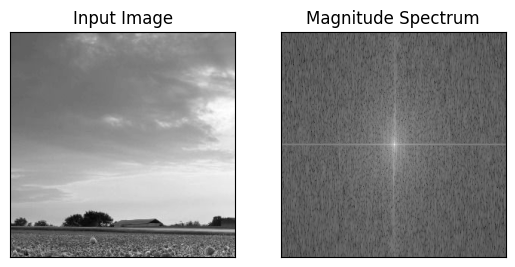

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


def plot_gray(input_image):
    """
    plot grayscale image with no axis
    """
    # plot grayscale image with gray colormap
    plt.imshow(input_image, cmap='gray')

    # turn off axis for easier view
    plt.axis('off')
    plt.show()


def plot_dft(crop_gray, magnitude_spectrum):
    plt.subplot(121),plt.imshow(crop_gray, cmap = 'gray')
    plt.title('Input Image'), plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
    plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
    plt.show()



def main():
    # read an image
    img = cv2.imread('./flowers_01.jpg')

    # create cropped grayscale image from the original image
    crop_gray = cv2.cvtColor(img[100:400, 100:400], cv2.COLOR_BGR2GRAY)

    # take discrete fourier transform
    dft = cv2.dft(np.float32(crop_gray),flags = cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

    # plot results
    plot_dft(crop_gray, magnitude_spectrum)



if __name__ == '__main__':
    main()

img2.shape=(50, 50, 1)


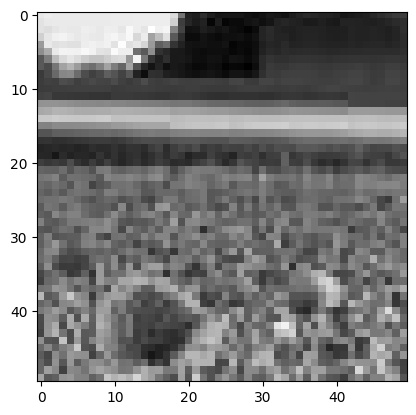

<ipython-input-11-58fdc5a9c785>:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dft2d[k,l] = sum_matrix


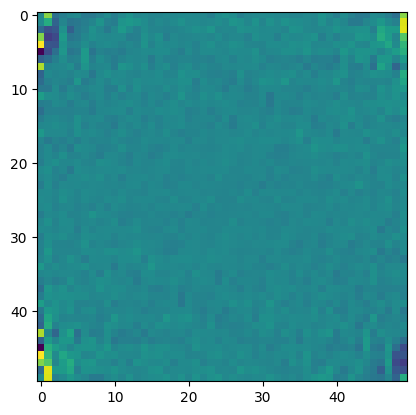

[[     0.           9901.91698243  -2557.28239665  -1030.07530788
      20.96238042    414.55860716  -1463.19890787  -1626.81991904]
 [   456.36194842   4303.1792633   -3875.47595572   -240.7207711
   -2040.14335088  -1729.70019918  -1033.75845922   -191.96990735]
 [ -3140.52414393  -6043.78379256  -5174.78878035   1208.93505329
   -4331.18797228  -1570.88937673   -714.32717007   1140.27883609]
 [  9660.21527643  -7806.7115537   -6612.99358967   2187.95889235
   -1974.07129404  -1270.6699804     -25.37521419    996.35694435]
 [ 14789.83925557  -5371.66811183  -5668.83920242   1374.45321133
    -803.64900746   -508.20743032    766.7392494    -565.62551668]
 [-12784.995362    -6287.97833372  -2717.79224644   1739.87927431
   -1986.00936757  -1335.03709437   2177.2398219   -2046.65851618]
 [ -4264.8401081   -2840.82896537   -913.84128293    696.4199792
    -726.06437205   -478.0166823    2089.82612701  -1012.97955607]
 [ 11506.52863527   -328.04087624    -22.94725266     93.22618278
     

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import cmath

import cv2

def DFT2D(image):
    data = np.asarray(image)
    #M, N = image.size # (img x, img y)
    M, N = image.shape[:2]
    dft2d = np.zeros((M,N),dtype=complex)
    for k in range(M):
        for l in range(N):
            sum_matrix = 0.0
            for m in range(M):
                for n in range(N):
                    e = cmath.exp(- 2j * np.pi * ((k * m) / M + (l * n) / N))
                    sum_matrix +=  data[m,n] * e
            dft2d[k,l] = sum_matrix
    return dft2d

#img = PIL.Image.open("flowers_01.jpg")
#img2 = img.resize((50,50))

# read an image
img = cv2.imread('./flowers_01.jpg')

# create cropped grayscale image from the original image
img2_ = cv2.cvtColor(img[350:400, 350:400], cv2.COLOR_BGR2GRAY)

img2 = img2_[:, :, np.newaxis]

print('img2.shape={}'.format(img2.shape))

plt.imshow(img2, cmap='gray')
plt.show()

dft = DFT2D(img2)

dft.real[0,0] = 0
plt.imshow(dft.real)
plt.show()

print(dft.real[:8, :8])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

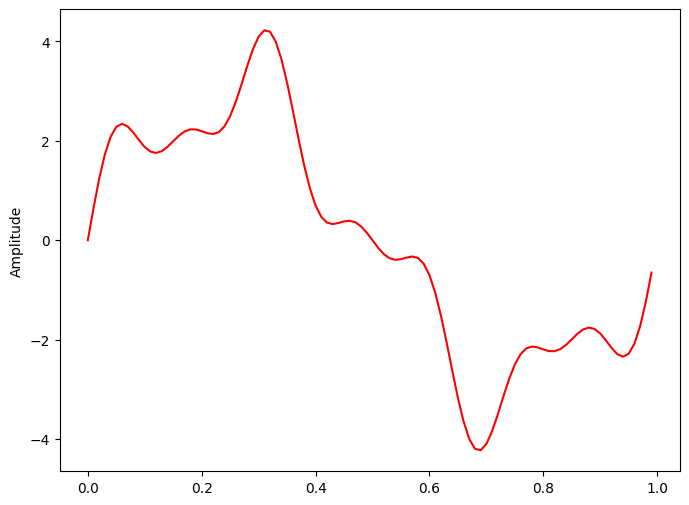

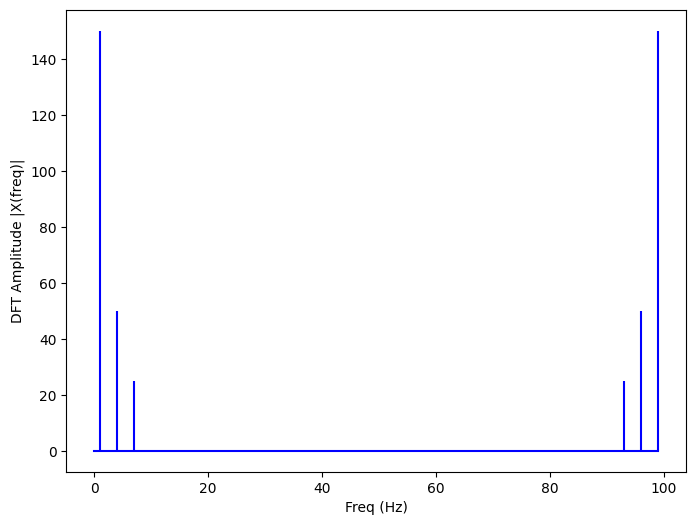

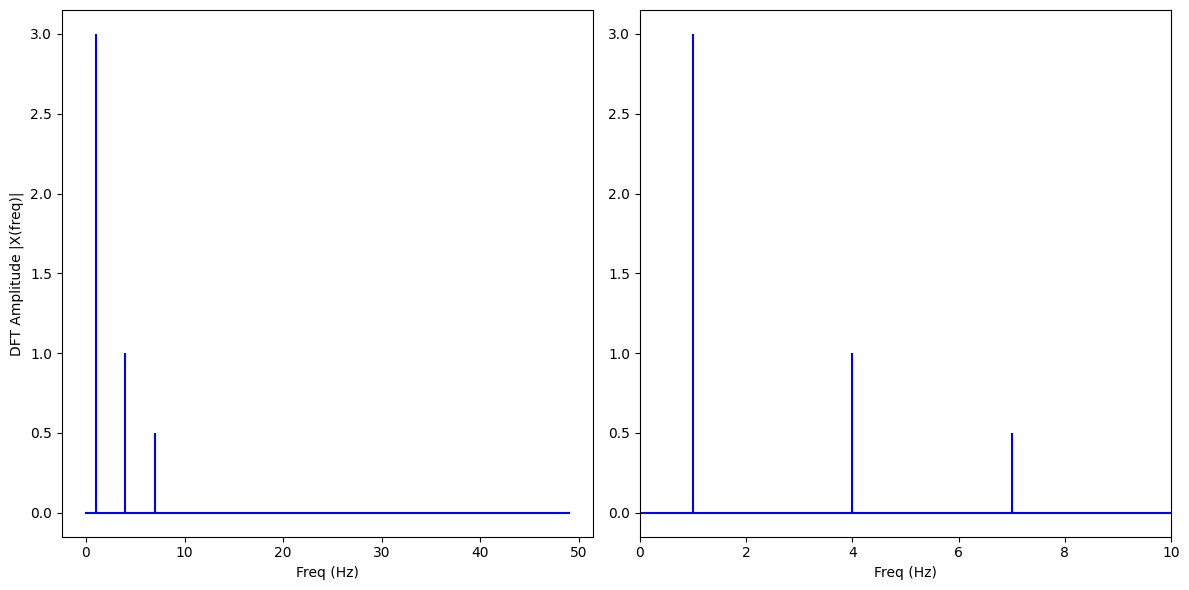

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# sampling rate
sr = 100
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

def DFT(x):
    """
    Function to calculate the
    discrete Fourier Transform
    of a 1D real-valued signal x
    """

    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j * np.pi * k * n / N)

    X = np.dot(e, x)

    return X

X = DFT(x)

# calculate the frequency
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (8, 6))
plt.stem(freq, abs(X), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.show()


# ============================================================


n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

# normalize the amplitude
X_oneside =X[:n_oneside]/n_oneside

plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')

plt.subplot(122)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

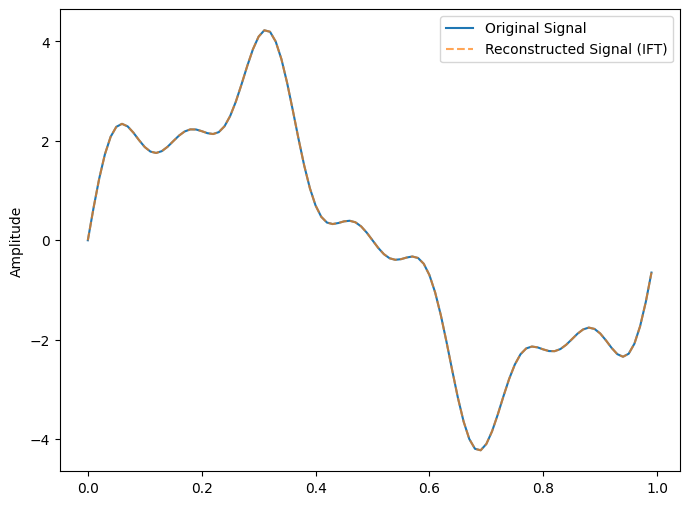

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def IFT(X):
    """
    Function to calculate the
    inverse discrete Fourier Transform
    of a 1D complex-valued signal X
    """
    N = len(X)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(2j * np.pi * k * n / N)

    x_reconstructed = np.dot(e, X) / N

    return x_reconstructed

x_reconstructed = IFT(X)

plt.figure(figsize=(8, 6))
plt.plot(t, x, label='Original Signal')
plt.plot(t, x_reconstructed.real, '--', label='Reconstructed Signal (IFT)', alpha=0.7)
plt.legend()
plt.ylabel('Amplitude')
plt.show()



Wykres dla odwrotnej transformaty Fouriera IFT (linia przerywana) jest taki sam jak dla sygnału oryginalnego, co oznacza że udało się odwrócić transformatę i implementacja jest poprawna.


Częstotliwość Nyquista to maksymalna częstotliwość, którą można prawidłowo próbkować bez aliasingu. Zgodnie z twierdzeniem o próbkowaniu, częstotliwość ta wynosi połowę częstotliwości próbkowania. W przypadku tego przykładu, gdzie częstotliwość próbkowania
sr=100Hz, częstotliwość Nyquista wynosi
50Hz. Oznacza to, że sygnały o częstotliwości powyżej tej wartości będą zniekształcone przez aliasing.


Na wykresie jednostronnym (częstotliwości dodatnie) przy DFT widać, że dominują częstotliwości w okolicach 1, 4 i 7 Hz, co jest zgodne z sygnałem generowanym przez sinusoidy o tych częstotliwościach.

Złożoność obliczeniowa DFT, IFT i DCT wynosi O(N^2).

00_data_aug skrypt

-0.42407447 -0.04093817 2.8215446


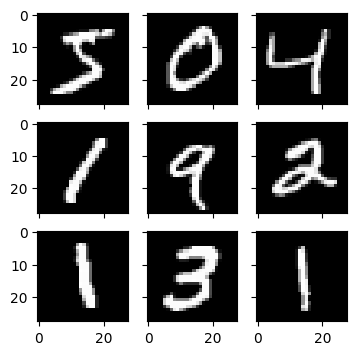

In [ ]:
# Standardize images across the dataset, mean=0, stdev=1
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

from matplotlib import pyplot as plt
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
datagen = ImageDataGenerator(featurewise_center=True, featurewise_std_normalization=True)
# fit parameters from data
datagen.fit(X_train)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9, shuffle=False):
    print(X_batch.min(), X_batch.mean(), X_batch.max())
    # create a grid of 3x3 images
    fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(4,4))
    for i in range(3):
        for j in range(3):
            ax[i][j].imshow(X_batch[i*3+j], cmap=plt.get_cmap("gray"))
    # show the plot
    plt.show()
    break

00_data_aug_mean_0_stdev_1.py skrypt

-1.2742625 -0.028436039 17.46127


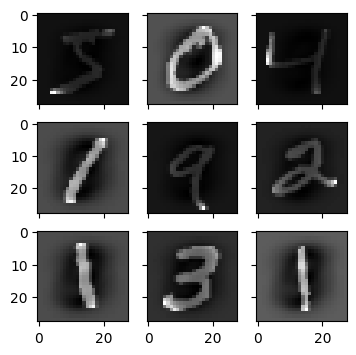

In [ ]:
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
datagen = ImageDataGenerator(featurewise_center=True, featurewise_std_normalization=True)
# fit parameters from data
datagen.mean = X_train.mean(axis=0)
datagen.std = X_train.std(axis=0)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9, shuffle=False):
    print(X_batch.min(), X_batch.mean(), X_batch.max())
    # create a grid of 3x3 images
    fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(4,4))
    for i in range(3):
        for j in range(3):
            ax[i][j].imshow(X_batch[i*3+j], cmap=plt.get_cmap("gray"))
    # show the plot
    plt.show()
    break

00_data_aug_ZCA_Whitening.py

/usr/local/lib/python3.10/dist-packages/keras/src/legacy/preprocessing/image.py:1054: UserWarning: This ImageDataGenerator specifies `zca_whitening` which overrides setting of`featurewise_std_normalization`.
  warnings.warn(


-12.411183 0.0038707666 17.104145


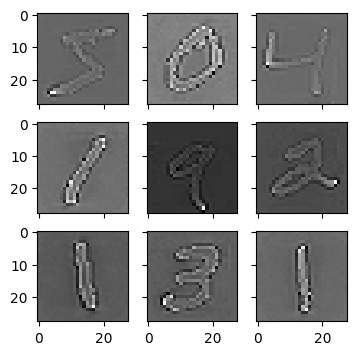

In [ ]:
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
datagen = ImageDataGenerator(featurewise_center=True, featurewise_std_normalization=True, zca_whitening=True)
# fit parameters from data
X_mean = X_train.mean(axis=0)
datagen.fit(X_train - X_mean)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train - X_mean, y_train, batch_size=9, shuffle=False):
    print(X_batch.min(), X_batch.mean(), X_batch.max())
    # create a grid of 3x3 images
    fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(4,4))
    for i in range(3):
        for j in range(3):
            ax[i][j].imshow(X_batch[i*3+j].reshape(28,28), cmap=plt.get_cmap("gray"))
    # show the plot
    plt.show()
    break

 01_data_aug.py skrypt

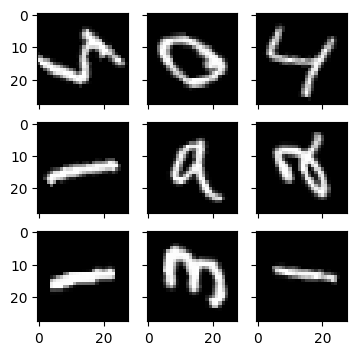

In [ ]:
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
datagen = ImageDataGenerator(rotation_range=90)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9, shuffle=False):
    # create a grid of 3x3 images
    fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(4,4))
    for i in range(3):
        for j in range(3):
            ax[i][j].imshow(X_batch[i*3+j].reshape(28,28), cmap=plt.get_cmap("gray"))
    # show the plot
    plt.show()
    break

02_data_aug.py

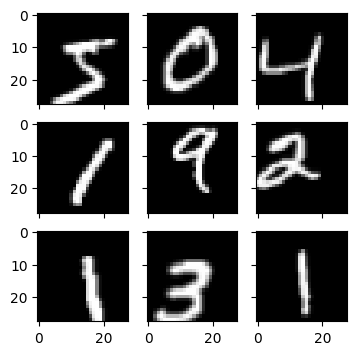

In [ ]:
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
shift = 0.2
datagen = ImageDataGenerator(width_shift_range=shift, height_shift_range=shift)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9, shuffle=False):
    # create a grid of 3x3 images
    fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(4,4))
    for i in range(3):
        for j in range(3):
            ax[i][j].imshow(X_batch[i*3+j].reshape(28,28), cmap=plt.get_cmap("gray"))
    # show the plot
    plt.show()
    break

03_data_aug.py skrypt

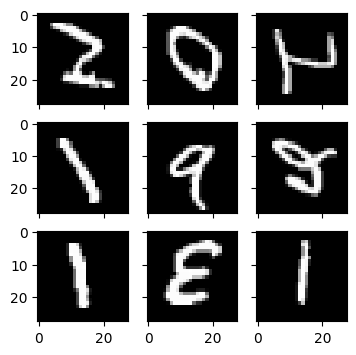

In [ ]:
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][width][height][channels]
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
# convert from int to float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# define data preparation
datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)
# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9, shuffle=False):
    # create a grid of 3x3 images
    fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(4,4))
    for i in range(3):
        for j in range(3):
            ax[i][j].imshow(X_batch[i*3+j].reshape(28,28), cmap=plt.get_cmap("gray"))
    # show the plot
    plt.show()
    break

mnist_data_aug_demo.py skrypt

X_train.shape=(60000, 28, 28) Y_train.shape=(60000,)


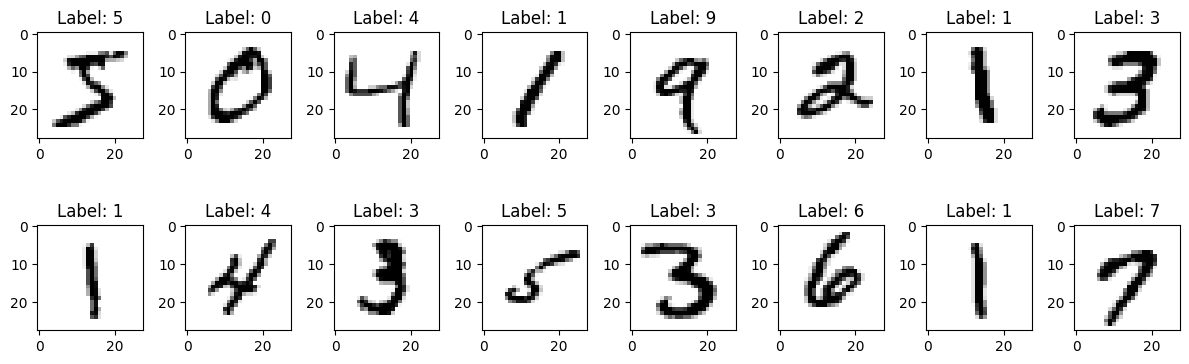

BEFORE:



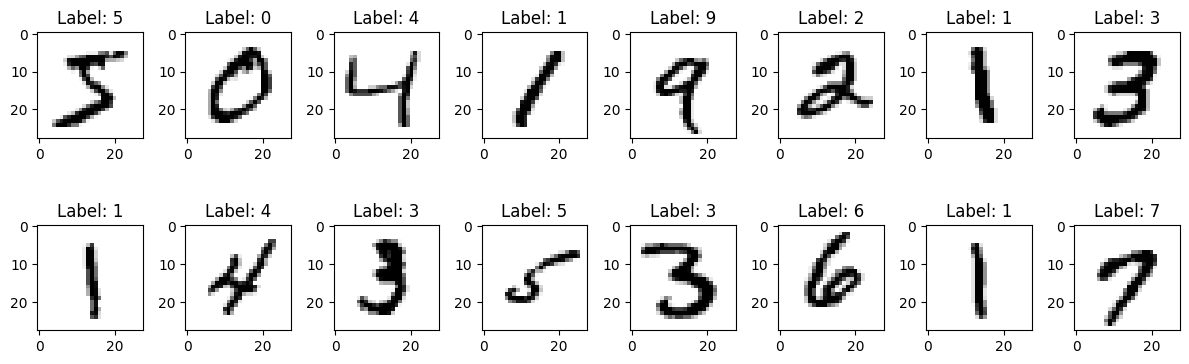

AFTER:



<ipython-input-25-b6a4f29f99b1>:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title('Label: {}'.format(int(Y[i])))


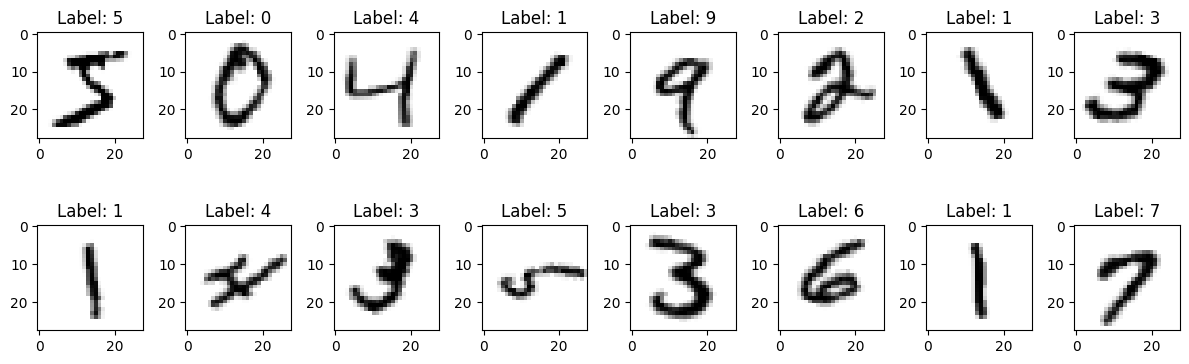

BEFORE:



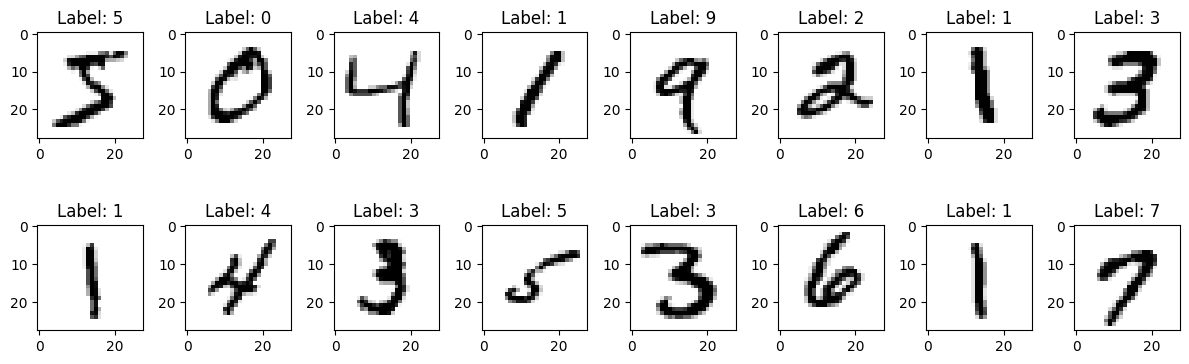

AFTER:



<ipython-input-25-b6a4f29f99b1>:101: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title('Label: {}'.format(int(Y[i])))


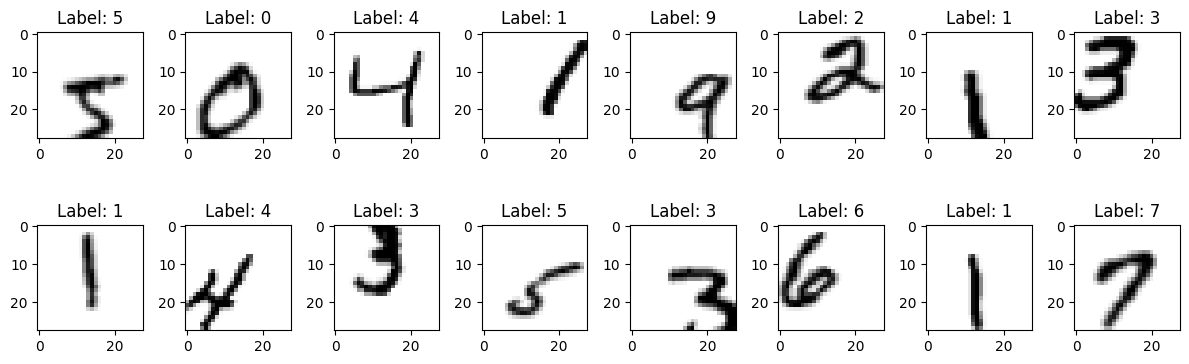

BEFORE:



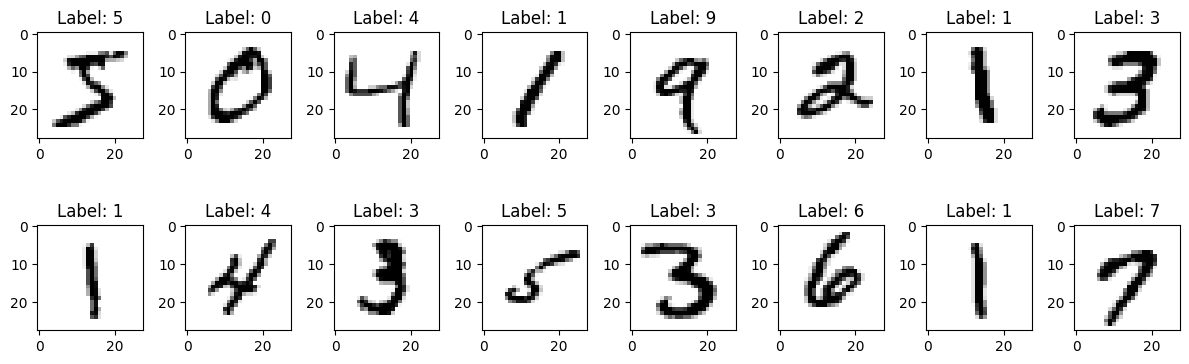

AFTER:



<ipython-input-25-b6a4f29f99b1>:136: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title('Label: {}'.format(int(Y[i])))


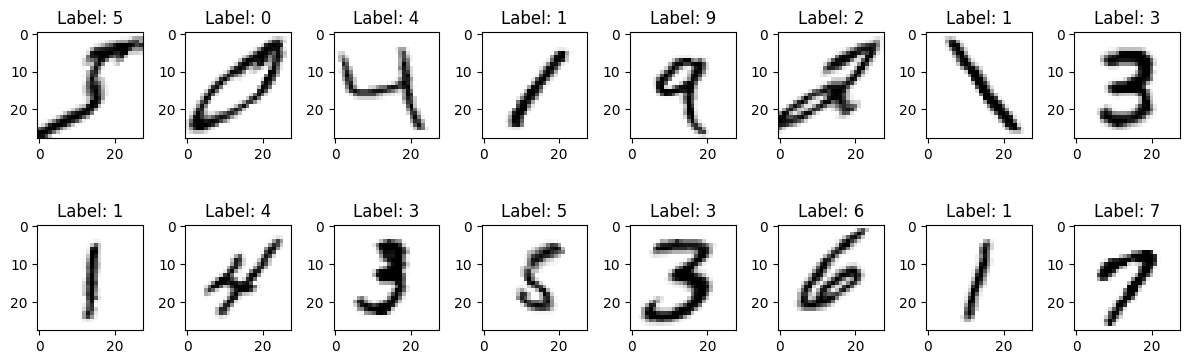

BEFORE:



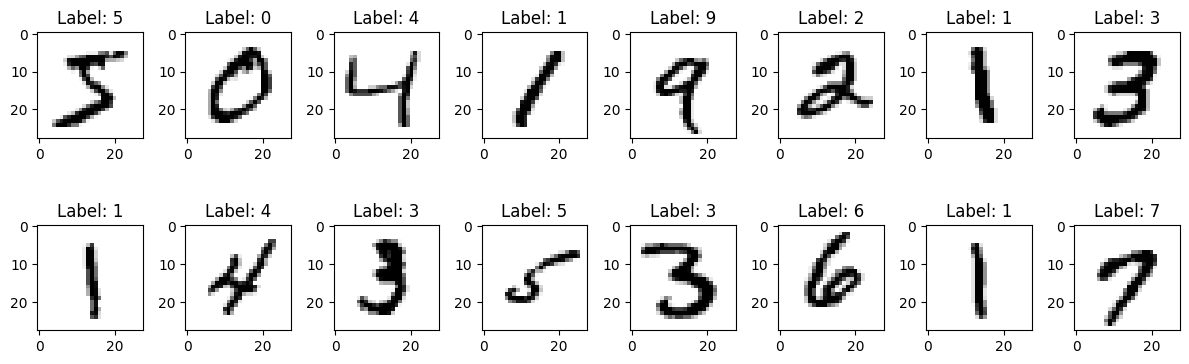

AFTER:



<ipython-input-25-b6a4f29f99b1>:172: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title('Label: {}'.format(int(Y[i])))


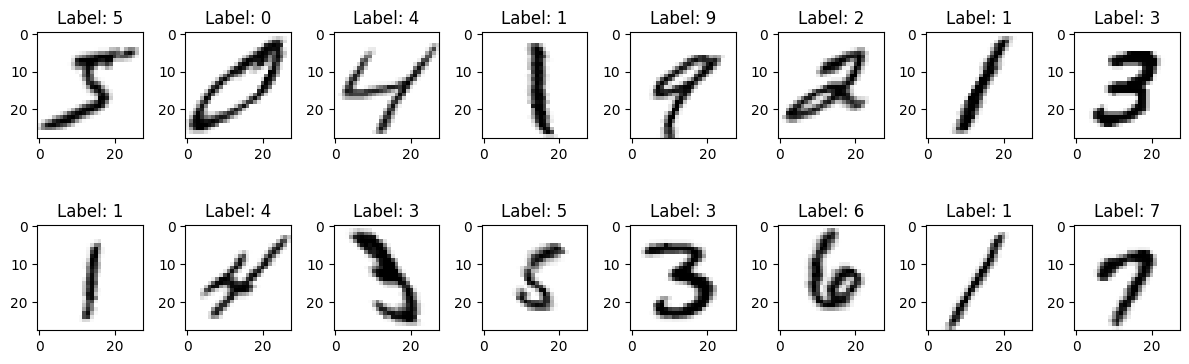

BEFORE:



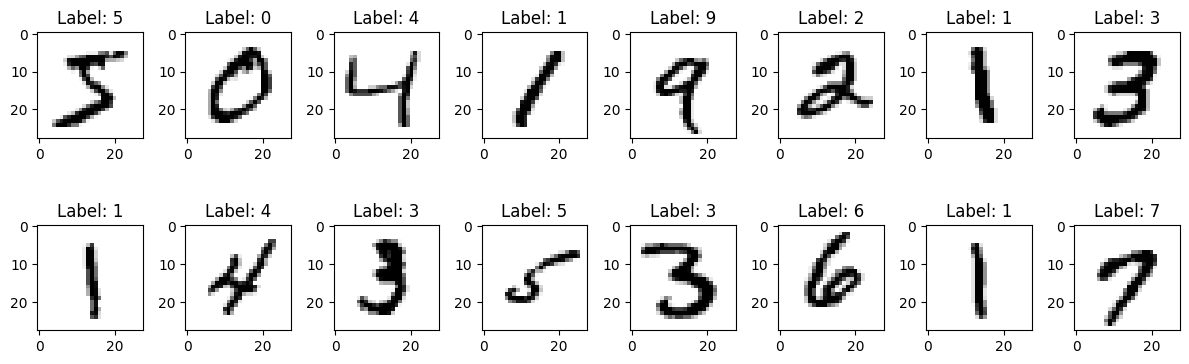

AFTER:



<ipython-input-25-b6a4f29f99b1>:207: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title('Label: {}'.format(int(Y[i])))


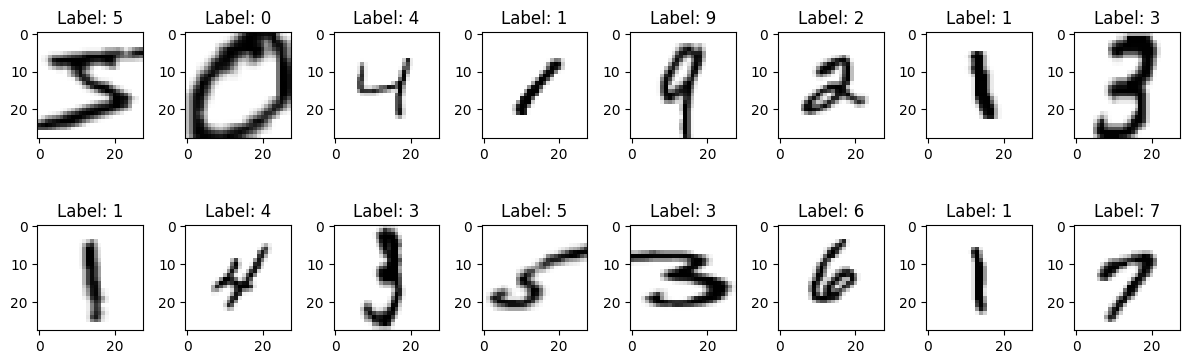

BEFORE:



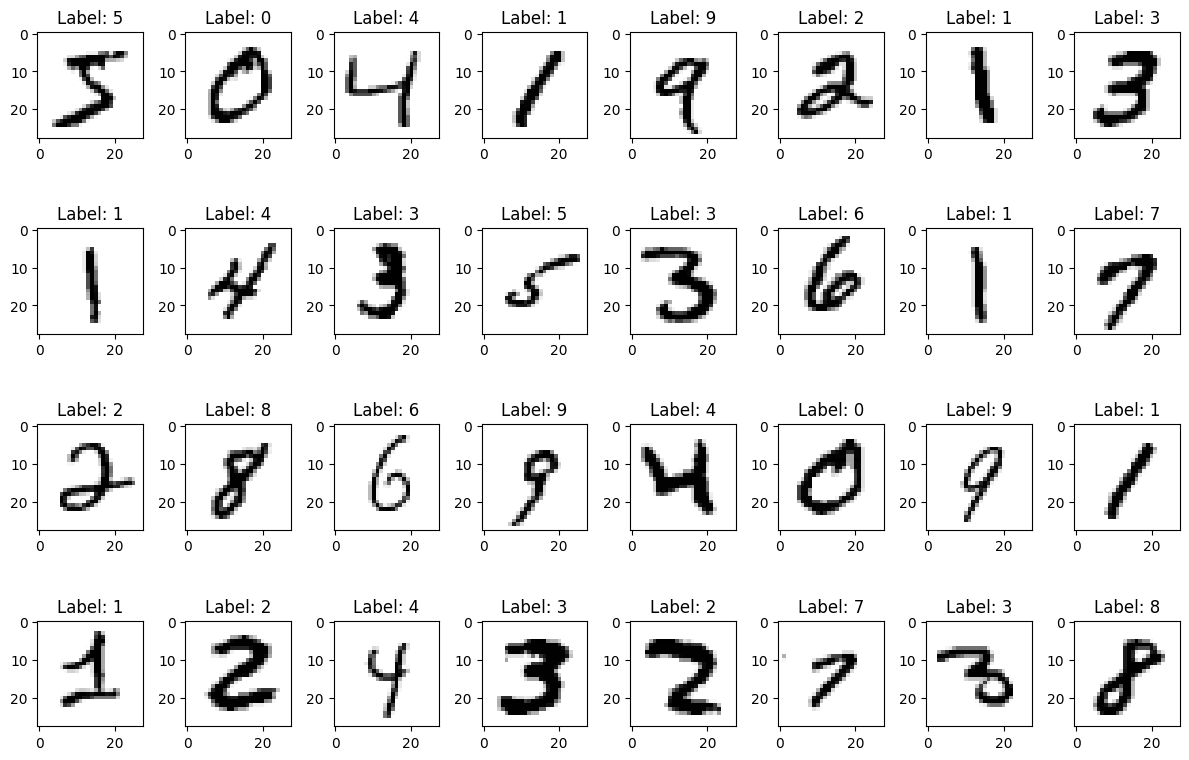

AFTER:



<ipython-input-25-b6a4f29f99b1>:247: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title('Label: {}'.format(int(Y[i])))


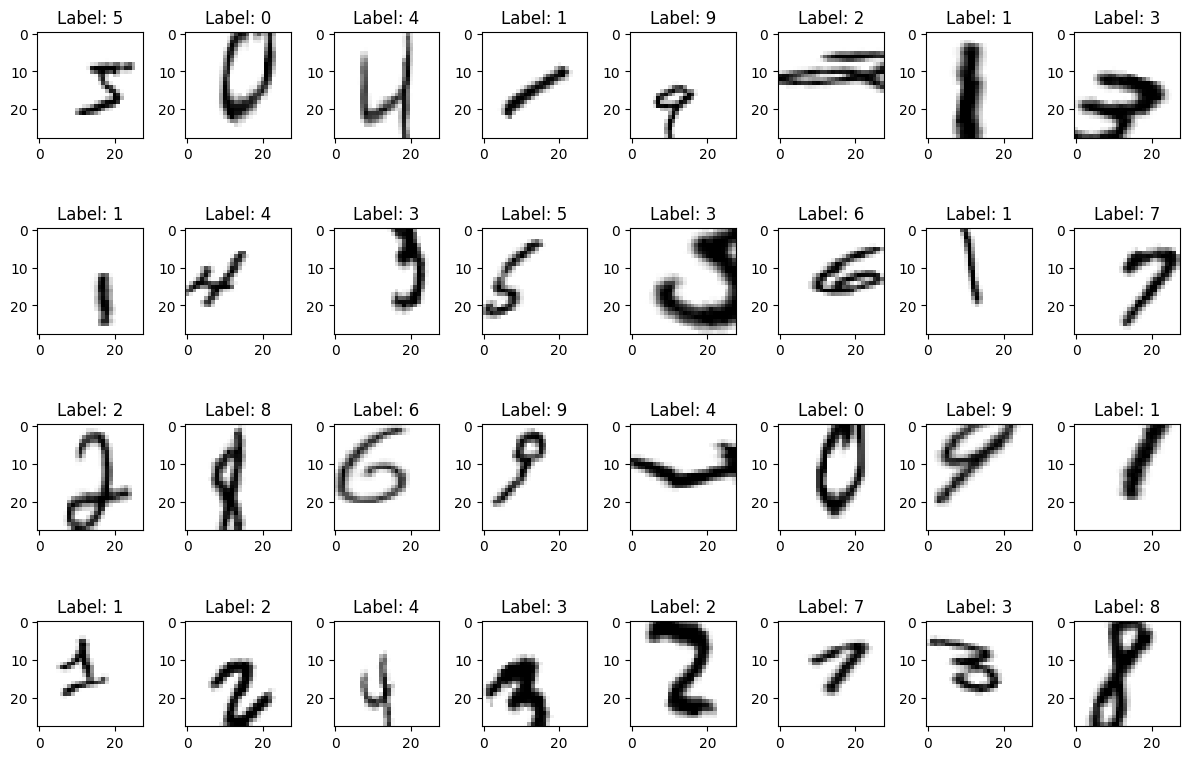

In [ ]:

# https://keras.io/api/preprocessing/image/

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

from matplotlib import pyplot as plt

from tensorflow.keras.datasets import mnist
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train.shape={} Y_train.shape={}'.format(X_train.shape, Y_train.shape))

# define number of images to show
num_row = 2
num_col = 8
num= num_row*num_col
# get images
images = X_train[0:num]
labels = Y_train[0:num]
# plot images
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes[i//num_col, i%num_col]
     ax.imshow(images[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(labels[i]))
plt.tight_layout()
plt.show()

# ==========================================================================

# Rotation

# specify the maximum rotation_range angle
rotation_range_val = 30
# import relevant library
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create the class object
datagen = ImageDataGenerator(rotation_range=rotation_range_val)
# fit the generator
datagen.fit(X_train.reshape(X_train.shape[0], 28, 28, 1))
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(X_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(Y_train[i]))
plt.tight_layout()
plt.savefig('out/data_before.png')
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen.flow(X_train.reshape(X_train.shape[0], 28, 28, 1),Y_train.reshape(Y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.savefig('out/data_after_data_aug.png')
plt.show()

# Shift
# specify the width and height shift arguments
width_shift_val = 0.25
height_shift_val = 0.25
# import relevant library
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create the class object
datagen = ImageDataGenerator(width_shift_range=width_shift_val, height_shift_range=height_shift_val)
# fit the generator
datagen.fit(X_train.reshape(X_train.shape[0], 28, 28, 1))
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(X_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(Y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen.flow(X_train.reshape(X_train.shape[0], 28, 28, 1),Y_train.reshape(Y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()

# Shear
# specify the shear argument
shear_range_val=45
# import relevant library
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create the class object
datagen = ImageDataGenerator(shear_range=shear_range_val)
# fit the generator
datagen.fit(X_train.reshape(X_train.shape[0], 28, 28, 1))
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(X_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(Y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen.flow(X_train.reshape(X_train.shape[0], 28, 28, 1),Y_train.reshape(Y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()

# Shear
# The shear transformation is used to displace pixels in a fixed direction (randomly selected up to shear_range value), by an amount proportional to its signed distance from the line that is parallel to that direction and goes through the origin.
# specify the shear argument
shear_range_val=45
# import relevant library
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create the class object
datagen = ImageDataGenerator(shear_range=shear_range_val)
# fit the generator
datagen.fit(X_train.reshape(X_train.shape[0], 28, 28, 1))
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(X_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(Y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen.flow(X_train.reshape(X_train.shape[0], 28, 28, 1),Y_train.reshape(Y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()

# Zoom
# specify the zoom argument
zoom_range_val=[0.5,1.5]
# import relevant library
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create the class object
datagen = ImageDataGenerator(zoom_range=zoom_range_val)
# fit the generator
datagen.fit(X_train.reshape(X_train.shape[0], 28, 28, 1))
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(X_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(Y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen.flow(X_train.reshape(X_train.shape[0], 28, 28, 1),Y_train.reshape(Y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()


# Augment The MNIST Dataset
# specify the arguments
rotation_range_val = 30
width_shift_val = 0.25
height_shift_val = 0.25
shear_range_val=45
zoom_range_val=[0.5,1.5]
# import relevant library
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create the class object
datagen = ImageDataGenerator(rotation_range = rotation_range_val,width_shift_range = width_shift_val,height_shift_range = height_shift_val,zoom_range=zoom_range_val,)
# fit the generator
datagen.fit(X_train.reshape(X_train.shape[0], 28, 28, 1))
# define number of rows & columns
num_row = 4
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(X_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(Y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen.flow(X_train.reshape(X_train.shape[0], 28, 28, 1),Y_train.reshape(Y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()